# Component 3 — Demand forecast: weekly model without leakage

This notebook replaces the evaluation in `inventory.ipynb` for the app's demand forecast. Two problems were found in
the original set-up:

1. **Target leakage in `shop inventory.csv`.** `rolling4_mean_units` there is the mean of the last four periods
   **including the period being predicted**, so part of the answer is inside a feature. The reported R² 0.931 is
   inflated by this (section 1).
2. **Wrong time scale for the app.** Rows in `shop inventory.csv` are 4–5 weeks apart (monthly), but the backend
   builds its lag features from **weekly** sales.

`demand_forecast_weekly.csv` (already in this folder, not used by `inventory.ipynb`) is truly weekly and its rolling
mean uses **past weeks only**, exactly how the backend computes it. This notebook trains on that file with a
**time split + 4-week gap**, compares against **naive baselines**, and saves the model under a **new file name**.
`inventory.ipynb`, both CSV files and `component3_demand_forecast_model.pkl` are not changed.

In [1]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

def load_weekly_ordered(path):
    d = pd.read_csv(path).drop_duplicates()
    d['week_start'] = pd.to_datetime(d['iso_year'].astype(str) + '-W' + d['iso_week'].astype(str).str.zfill(2) + '-1',
                                     format='%G-W%V-%u')
    return d.sort_values(['item', 'week_start']).reset_index(drop=True)

def make_pipeline(estimator, num_cols, cat_cols=('item', 'category')):
    pre = ColumnTransformer([
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore'))]), list(cat_cols)),
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ])
    return Pipeline([('pre', pre), ('m', estimator)])

## 1. The leakage in `shop inventory.csv`

In [2]:
old = load_weekly_ordered('shop inventory.csv').drop(columns=['target_next_month_price'], errors='ignore')
g = old.groupby('item')
incl_current = g['target_units_sold'].transform(lambda s: s.rolling(4, min_periods=1).mean())
past_only = g['target_units_sold'].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
print(f"rolling4_mean_units == mean(t-3 .. t, INCLUDING the target): {np.isclose(old['rolling4_mean_units'], incl_current, atol=0.51).mean():.3f}")
print(f"rolling4_mean_units == mean(t-4 .. t-1, past only)          : {np.isclose(old['rolling4_mean_units'], past_only, atol=0.51).mean():.3f}")
print('Weeks between consecutive rows of an item:', (g['week_start'].diff().dt.days / 7).value_counts().head(3).to_dict())

fixed = old.copy()
fixed['rolling4_mean_units'] = past_only
fixed['rolling4_mean_price'] = g['avg_retail_price_rs'].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
train = old['iso_year'] < 2024          # same temporal split as inventory.ipynb
rows = []
for label, data in [('as trained (leak)', old), ('leak removed', fixed)]:
    X = data.drop(columns=['target_units_sold', 'week_start']); y = data['target_units_sold']
    num = [c for c in X.columns if c not in ('item', 'category')]
    m = make_pipeline(RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE), num)
    p = m.fit(X[train], y[train]).predict(X[~train])
    rows.append({'shop inventory.csv': label, 'RandomForest MAE': mean_absolute_error(y[~train], p), 'R²': r2_score(y[~train], p)})
pd.DataFrame(rows).set_index('shop inventory.csv').round(3)

rolling4_mean_units == mean(t-3 .. t, INCLUDING the target): 1.000
rolling4_mean_units == mean(t-4 .. t-1, past only)          : 0.044
Weeks between consecutive rows of an item: {4.0: 1508, 5.0: 833, 13.0: 16}


,RandomForest MAE,R²
shop inventory.csv,,
as trained (leak),21.557,0.931
leak removed,26.916,0.889


With the leak removed the same model drops from R² ≈ 0.93 to ≈ 0.89 — the earlier number should not be reported
as the model's accuracy.

## 2. The weekly dataset

In [3]:
df = load_weekly_ordered('demand_forecast_weekly.csv')
g = df.groupby('item')
print(f"Rows {len(df)} | items {df['item'].nunique()} | {df['week_start'].min().date()} -> {df['week_start'].max().date()}")
print('Weeks between consecutive rows:', (g['week_start'].diff().dt.days / 7).value_counts().head(3).to_dict())
print('Categories:', df['category'].unique().tolist())
checks = {
    'lag1_units == units last week': (df['lag1_units'], g['target_units_sold'].shift(1)),
    'lag4_units == units 4 weeks ago': (df['lag4_units'], g['target_units_sold'].shift(4)),
    'rolling4_mean_units == mean of the 4 PAST weeks': (df['rolling4_mean_units'],
        g['target_units_sold'].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())),
}
for name, (a, b) in checks.items():
    m = a.notna() & b.notna()
    print(f'{name:48s}: {np.isclose(a[m], b[m], atol=0.51).mean():.3f}')
print('weekend_share values:', df['weekend_share'].value_counts().to_dict())

Rows 5434 | items 26 | 2022-06-13 -> 2026-06-08
Weeks between consecutive rows: {1.0: 5408}
Categories: ['Vegetable/Fruit', 'Grocery/Staple']
lag1_units == units last week                   : 1.000
lag4_units == units 4 weeks ago                 : 1.000
rolling4_mean_units == mean of the 4 PAST weeks : 1.000
weekend_share values: {0.29: 5408, 0.0: 26}


All three lag features use **past weeks only** — no leakage, and the same definitions the backend uses
(`backend/src/utils/features.js`, `buildDemandFeatures`). `weekend_share` is effectively constant (0.29), so the
backend sends 0.29.

## 3. Time split with a 4-week gap, and time-based CV

In [4]:
X = df.drop(columns=['target_units_sold', 'week_start'])
y = df['target_units_sold'].astype(float)
num_cols = [c for c in X.columns if c not in ('item', 'category')]

GAP = pd.Timedelta(weeks=4)
TEST_START = pd.Timestamp('2025-07-01')
dev = (df['week_start'] < TEST_START - GAP).values
test = (df['week_start'] >= TEST_START).values
X_dev, y_dev, X_test, y_test = X[dev], y[dev], X[test], y[test]
print(f"Development: {dev.sum()} rows (-> {df.loc[dev, 'week_start'].max().date()}) | gap: {(~dev & ~test).sum()} | "
      f"test: {test.sum()} rows ({df.loc[test, 'week_start'].min().date()} -> {df.loc[test, 'week_start'].max().date()})")

dev_weeks = df.loc[dev, 'week_start'].reset_index(drop=True)
cuts = pd.date_range(dev_weeks.min() + pd.Timedelta(weeks=52), dev_weeks.max(), periods=5)
time_folds = [(np.where(dev_weeks < a - GAP)[0], np.where((dev_weeks >= a) & (dev_weeks < b))[0])
              for a, b in zip(cuts[:-1], cuts[1:])]
for i, (tr, va) in enumerate(time_folds, 1):
    print(f'Fold {i}: train {len(tr)} rows -> validate {dev_weeks.iloc[va].min().date()} .. {dev_weeks.iloc[va].max().date()} ({len(va)})')

Development: 4056 rows (-> 2025-06-02) | gap: 104 | test: 1274 rows (2025-07-07 -> 2026-06-08)
Fold 1: train 1248 rows -> validate 2023-06-12 .. 2023-12-04 (676)
Fold 2: train 1924 rows -> validate 2023-12-11 .. 2024-06-03 (676)
Fold 3: train 2600 rows -> validate 2024-06-10 .. 2024-12-02 (676)
Fold 4: train 3276 rows -> validate 2024-12-09 .. 2025-05-26 (650)


## 4. Model comparison (time-based CV, MAE in units per week)

In [5]:
estimators = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=250, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.9, random_state=RANDOM_STATE),
}
cv_mae = {}
for name, est in estimators.items():
    maes = []
    for tr, va in time_folds:
        p = make_pipeline(clone(est), num_cols).fit(X_dev.iloc[tr], y_dev.iloc[tr]).predict(X_dev.iloc[va])
        maes.append(mean_absolute_error(y_dev.iloc[va], p))
    cv_mae[name] = (np.mean(maes), np.std(maes))
    print(f'  {name:18s} | time-CV MAE {np.mean(maes):6.2f} ± {np.std(maes):.2f}')
best_name = min(cv_mae, key=lambda k: cv_mae[k][0])
print(f'\nChampion (validation folds only): {best_name}')

  LinearRegression   | time-CV MAE  11.43 ± 2.01


  DecisionTree       | time-CV MAE   9.96 ± 1.80


  RandomForest       | time-CV MAE   9.88 ± 2.03


  GradientBoosting   | time-CV MAE  10.03 ± 1.83


  XGBoost            | time-CV MAE  10.07 ± 1.96

Champion (validation folds only): RandomForest


## 5. Final test on the future period (used once) and baselines

In [6]:
model = make_pipeline(clone(estimators[best_name]), num_cols).fit(X_dev, y_dev)
pred = model.predict(X_test)
results = {
    f'ML: {best_name}': pred,
    'Naive: same as last week': X_test['lag1_units'].values,
    'Naive: mean of the past 4 weeks': X_test['rolling4_mean_units'].values,
}
table = pd.DataFrame({k: {'MAE': mean_absolute_error(y_test, v),
                          'RMSE': np.sqrt(mean_squared_error(y_test, v)),
                          'R²': r2_score(y_test, v)} for k, v in results.items()}).T
test_mae, test_rmse, test_r2 = table.iloc[0]
best_naive = table.iloc[1:]['MAE'].min()
print(f'ML MAE is {(1 - test_mae / best_naive) * 100:.1f}% lower than the best naive baseline')
table.round(3)

ML MAE is 21.7% lower than the best naive baseline


,MAE,RMSE,R²
ML: RandomForest,10.89,24.786,0.908
Naive: same as last week,13.90,30.489,0.861
Naive: mean of the past 4 weeks,14.15,31.157,0.855


## 6. Charts

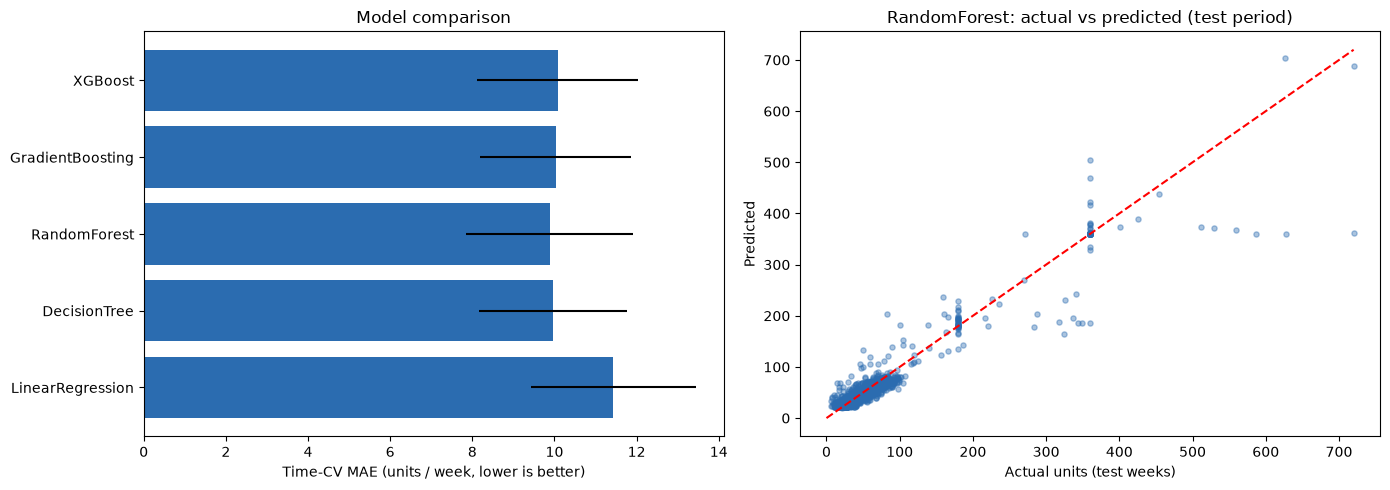

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(list(cv_mae), [v[0] for v in cv_mae.values()], xerr=[v[1] for v in cv_mae.values()], color='#2b6cb0')
axes[0].set_xlabel('Time-CV MAE (units / week, lower is better)'); axes[0].set_title('Model comparison')
axes[1].scatter(y_test, pred, alpha=0.4, s=14, color='#2b6cb0')
lims = [0, max(y_test.max(), pred.max())]
axes[1].plot(lims, lims, 'r--'); axes[1].set_xlabel('Actual units (test weeks)'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'{best_name}: actual vs predicted (test period)')
plt.tight_layout(); plt.savefig('component3_weekly_performance.png', dpi=120); plt.show()

## 7. Safety stock (weekly units)

`safety stock = Z × forecast RMSE × √(lead time in weeks)`, with Z = 1.65 (≈95 % service level). The forecast error
is the **weekly** test RMSE, so the lead time must also be in **weeks** (inventory `lead_time_days / 7`).

In [8]:
Z = 1.65
def reorder_level(forecast_units_per_week, lead_time_days):
    weeks = max(lead_time_days, 1) / 7
    safety = Z * test_rmse * np.sqrt(weeks)
    return round(forecast_units_per_week * weeks + safety), round(safety)

for lt in (1, 3, 7, 14):
    level, safety = reorder_level(float(np.median(pred)), lt)
    print(f'lead time {lt:2d} days: reorder when stock < {level} units (includes safety stock {safety})')

lead time  1 days: reorder when stock < 22 units (includes safety stock 15)
lead time  3 days: reorder when stock < 45 units (includes safety stock 27)
lead time  7 days: reorder when stock < 84 units (includes safety stock 41)
lead time 14 days: reorder when stock < 144 units (includes safety stock 58)


## 8. Model for the app

Refit the champion on **all** weeks and save under a new name. It is a plain scikit-learn `Pipeline` with the same
input columns the backend sends, so `ml_service/app.py` can load it without changes: copy it over
`ml_service/models/component3_demand_forecast_model.pkl` (keep a backup of the old file).

In [9]:
final_model = make_pipeline(clone(estimators[best_name]), num_cols).fit(X, y)
joblib.dump(final_model, 'component3_demand_forecast_weekly.pkl', compress=3)
print('Saved component3_demand_forecast_weekly.pkl')
print({'champion': best_name, 'test_mae': round(test_mae, 2), 'test_rmse': round(test_rmse, 2), 'test_r2': round(test_r2, 3),
       'inputs': list(final_model.feature_names_in_)})

Saved component3_demand_forecast_weekly.pkl
{'champion': 'RandomForest', 'test_mae': 10.89, 'test_rmse': 24.79, 'test_r2': 0.908, 'inputs': ['item', 'category', 'iso_year', 'iso_week', 'days_to_avurudu', 'festival_season', 'avg_wholesale_price_rs', 'avg_retail_price_rs', 'lag1_units', 'lag4_units', 'rolling4_mean_units', 'weekend_share']}
